# Интеллектуальный анализ данных – весна 2025
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [1]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
6323,11476,56428,"London, England",19-03-2020,The average price of properties on sale across...,Positive
7007,12320,57272,"Lagos, Nigeria",19-03-2020,4 of 5 ...how does the #Coronavirus affect tho...,Positive
18205,25948,70900,"Billings, MT",25-03-2020,Entryway in my house\r\r\nTHANK YOU FOR VISITI...,Extremely Positive
7499,12902,57854,"Irvine,CA",20-03-2020,#Capitalism allowed me to buy almost everythin...,Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

In [4]:
df.Sentiment.unique()

array(['Positive', 'Extremely Negative', 'Negative', 'Extremely Positive'],
      dtype=object)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [5]:

df['SentimentBin'] = df['Sentiment'].map({
    'Positive': 1,
    'Extremely Positive': 1,
    'Negative': 0,
    'Extremely Negative': 0
})
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,SentimentBin
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive,1
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive,1
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative,0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,Positive,1


Сбалансированы ли классы?

In [6]:
sentiment_pos = df['SentimentBin'].value_counts().reset_index()
sentiment_pos['PartOfGs'] = round(100*sentiment_pos['count']/sentiment_pos['count'].sum(), 1)
sentiment_pos

,SentimentBin,count,PartOfGs
0,1,18046,54.0
1,0,15398,46.0


**Ответ:** Классы почти сбалансированы, но с небольшой склонностью в сторону положительных твитов

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [7]:
df.isna().sum()

,0
UserName,0
ScreenName,0
Location,7049
TweetAt,0
OriginalTweet,0
Sentiment,0
SentimentBin,0


In [8]:
df = df.fillna('Unknown')
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,SentimentBin
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive,1
2,3802,48754,Unknown,16-03-2020,My food stock is not the only one which is emp...,Positive,1
3,3803,48755,Unknown,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative,0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,Positive,1


Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [9]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state = 0)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [10]:
from collections import Counter

token_cnter = Counter()

for t in train.OriginalTweet:
  tokens = t.lower().split()
  token_cnter.update(tokens)
token_cnter



Counter({'why': 654,
         'we': 3787,
         'still': 763,
         'want': 487,
         'to': 23373,
         'buy': 748,
         'so': 1837,
         'much': 482,
         'stuff': 106,
         'during': 1908,
         'quarantine': 154,
         'https://t.co/1m881cwfuv': 1,
         '#shopping': 121,
         '#covid_19': 1660,
         '#online': 40,
         'with': 4063,
         'driving': 77,
         'even': 682,
         'more': 2008,
         'usage': 22,
         'a': 11737,
         'strong': 93,
         'strategy': 33,
         'is': 7383,
         'critical': 156,
         'now': 1349,
         'then': 435,
         'ever': 179,
         'luckily': 8,
         'and': 14684,
         'april': 163,
         '16': 36,
         'webinar': 65,
         'will': 2726,
         'dive': 10,
         'into': 666,
         'growing': 84,
         'app': 52,
         'awareness': 32,
         'targeting': 9,
         'high': 408,
         'lifetime': 4,
         'value': 

Какой размер словаря получился?

In [11]:
len(token_cnter)

79755

Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [12]:
best_tokens = pd.DataFrame(token_cnter.most_common(10), columns=['token', 'count'])
best_tokens


,token,count
0,the,26815
1,to,23373
2,and,14684
3,of,13012
4,a,11737
5,in,11198
6,for,8566
7,#coronavirus,8223
8,is,7383
9,are,7050


**Ответ:** Наиболее часто встречаются артикли и предлоги, что вполне объяснимо стандартной структурой предложений (эти слова встречаются во всех предложениях вне зависимости от контекста) + глаголы is и are наиболее распространены в описании событий, состояний и чувств (также являются универсальными и применяются в любом контексте)
Также к этим токенам примешивается тег #coronavirus, что объясняется тем, что все твиты перекликаются с коронавирусом по тематике

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [13]:
!pip install nltk

In [14]:
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)

stop_words = stopwords.words("english")

for token in list(token_cnter):
  if token in stop_words:
    token_cnter.pop(token)

new_best = pd.DataFrame(token_cnter.most_common(10), columns=['token', 'count'])
new_best


,token,count
0,#coronavirus,8223
1,prices,3891
2,food,3820
3,grocery,3469
4,supermarket,3288
5,people,3175
6,covid-19,3173
7,store,3155
8,#covid19,2471
9,&amp;,2314


**Ответ:**  Теперь, после избавления универсальных "шумовых" слов можно увидеть среди наиболее часто встречающихся те слова, которые часто используются в контексте обсуждения влияния коронавируса (цены, еда, люди, магазины). Также среди них все еще остается два хэштега, что вполне объяснимо тем, что все твиты по одной тематике.

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [15]:
least_tokens = pd.DataFrame(token_cnter.most_common()[-20:], columns = ['token', 'count'])
least_tokens

,token,count
0,skellig,1
1,coast!,1
2,closer!),1
3,@skelligsix18,1
4,#skelligcoast2kms,1
5,#southkerry,1
6,https://t.co/zjcl195vqs,1
7,@srinivasiyc,1
8,https://t.co/iaek4fwsgz,1
9,premiership,1


**Ответ:** По большей части наименее частые токены являются таковыми из-за того, что изначально мы разделили их только по пробелам -- то есть слова записывваются вместе со знаками препинания, что отделяет их от того же слова в чистом виде (например, "closer!)")

Также, среди наименее популярных слов можно заметить ссылки на аккаунты людей, что вполне объяснимо (вряд ли при обсуждении ковида все будут тегать одного и того же неизвестного человека много раз)

Есть и сокращения (dec.), а также числовые значения, выражающие сумму денег.

Стоит отметить еще формы слов, которые входят сюда, однако могут встречаться в большем количестве в другой форме (flew)



Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [16]:
from nltk.tokenize import TweetTokenizer
tweet_cnter = Counter()
tw = TweetTokenizer()

for t in train.OriginalTweet:
  tokens = tw.tokenize(t.lower())
  tweet_cnter.update(tokens)

best_tweet_tokens = pd.DataFrame(tweet_cnter.most_common()[:10], columns = ['token', 'count'])
best_tweet_tokens


,token,count
0,the,26993
1,.,24118
2,to,23478
3,",",17571
4,and,14825
5,of,13044
6,a,11891
7,in,11348
8,?,9524
9,#coronavirus,8808


**Ответ:** Теперь к предлогам в наиболее часто встречающихся токенах примешивается пунктуация, что вполне логично: теперь пунктуация записывается отдельными токенами, а это одно из необходимых условий составления предложения.

Среди них наиболее популярны запятая, точка и вопрос

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [17]:
from string import punctuation

stops = stopwords.words("english") + list(punctuation)
for t in list(tweet_cnter):
  if t in stops:
    tweet_cnter.pop(t)

new_best_tweet = pd.DataFrame(tweet_cnter.most_common()[:10], columns = ['token', 'count'])
new_best_tweet

,token,count
0,#coronavirus,8808
1,â,7415
2,,7311
3,19,7167
4,covid,6253
5,prices,4601
6,,4372
7,food,4367
8,store,3877
9,supermarket,3805


**Ответ:** Уже можно видеть более менее избавленные от шума слова, имеющие смысл и отношение к коронавирусу и контексту, однако все равно остались символы, не несущие под собой смысловую нагрузку (â, , ) - скорее всего среди них есть эмодзи



Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [18]:
for t in list(tweet_cnter):
  if len(t) == 1 and ord(t) >= 128:
    tweet_cnter.pop(t)

final_best_tweet = pd.DataFrame(tweet_cnter.most_common()[:10], columns = ['token', 'count'])
final_least_tweet = pd.DataFrame(tweet_cnter.most_common()[-20:], columns = ['token', 'count'])
final_best_tweet

,token,count
0,#coronavirus,8808
1,19,7167
2,covid,6253
3,prices,4601
4,food,4367
5,store,3877
6,supermarket,3805
7,grocery,3523
8,people,3463
9,#covid19,2589


In [19]:
final_least_tweet

,token,count
0,https://t.co/lw1r0rm7xs,1
1,https://t.co/5cbliqzx7l,1
2,now.when,1
3,milion,1
4,skellig,1
5,@skelligsix18,1
6,#skelligcoast2kms,1
7,#southkerry,1
8,https://t.co/zjcl195vqs,1
9,@srinivasiyc,1


**Ответ:** По сравнению с токенизацией обычным сплитом по пробелам в данном случае среди наиболее часто встречающихся токенов можно видеть содержащие смысл и отношение к контексту коронавируса слова (в первоначальном варианте было много предлогов и артиклей)

В самые часто встречающиеся попадает число 19 — артефакт хэштегов, что все еще зашумляет токены


Среди наименее часто встречающихся можно заметить выброс со знаком пунктуации - "now.when", что скорее всего связано с особенностью токенизатора, из-за которой он не видит . так как точка стоит в середине слова и воспринимается токенизатором как часть слова (аналогично с дефисом в non-playing)

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [20]:
tegs = tweet_cnter.copy()
for t in list(tegs):
  if t[0] != '#':
    tegs.pop(t)

heshtegs = pd.DataFrame(tegs.most_common()[:10], columns = ['teg', 'count'])
heshtegs

,teg,count
0,#coronavirus,8808
1,#covid19,2589
2,#covid_19,1734
3,#covid2019,946
4,#toiletpaper,744
5,#covid,641
6,#socialdistancing,465
7,#coronacrisis,448
8,#pandemic,257
9,#coronaviruspandemic,249


**Ответ:** Среди наиболее популярных хэштегов в твитах о коронавирусе ожидаемо было увидеть теги, содержащие само название темы твитов - одно и то же понятие может быть выражено разными хэштегами, что усложняет анализ токенов,

Cамый частый - coronavirus, также есть пандемия и социальная дистанция, что описывает последствия коронавируса и по большей части уже ассоциируются именно с ковидом.
Туалетная бумага, видимо, наболее наболевшая тема у пользователей в рамках обсуждения коронавируса


То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [21]:
https_tokens = tweet_cnter.copy()
for t in list(https_tokens):
  if not t.startswith('https://t.co'):
    https_tokens.pop(t)

http_cnter = pd.DataFrame(https_tokens.most_common()[:10], columns = ['https_token', 'count'])
http_cnter


,https_token,count
0,https://t.co/oxa7swtond,5
1,https://t.co/gp3eusapl8,4
2,https://t.co/deftrui1pfãâ,3
3,https://t.co/wrlhyzizaa,3
4,https://t.co/kuwipf1kqw,3
5,https://t.co/zjnrx6dkkn,3
6,https://t.co/3gbbdpdjat,3
7,https://t.co/e2znxajpre,3
8,https://t.co/catkegayoy,3
9,https://t.co/g63rp042ho,3


**Ответ:** Среди ссылок https://t.co наибольшая частота - 5, в то время как у хэштегов она по всем топам тегов больше 200, а максимальная = 8808

хэштеги по большей части являются чем-то вроде необходимого условия твита, которое используется в 99% твитов, в то время как ссылки являются скорее исключениями в виде атрибутов

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [22]:
tw = TweetTokenizer()
stops = stopwords.words("english") + list(punctuation)
def custom_tokenizer(text):
  tokens = [t for t in tw.tokenize(text.lower()) if (t not in stops) and not (len(t) == 1 and ord(t) >= 128) and not (t.startswith('https://t.co'))]
  return tokens


In [23]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer = custom_tokenizer)
x_train = train.OriginalTweet
y_train = train.SentimentBin

X = cv.fit_transform(x_train)


print(len(cv.vocabulary_))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


45290


**Ответ:** В задании 2 размер получившегося словаря на обучающей выборке был равен 79755, здесь получается, что размер в 1.76 раз меньше предудущего

Видимо было слишком много шумовых токенов, которые отфильтровались в custom_tokenizer, включая стоп слова, пунктуацию, ссылки и элементы с позицией Unicode 128 и более

Посмотрим на какой-нибудь конкретный твитт:

In [25]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 'Negative')

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [26]:
counts = cv.transform([train.iloc[ind]['OriginalTweet']]).toarray()[0]
ids = counts.nonzero()
tokens = cv.get_feature_names_out()

ind_counts = pd.DataFrame(columns = ['token', 'count'])
for i in ids:
  ind_counts = pd.concat([ind_counts, pd.DataFrame({'token': tokens[i], 'count': counts[i]})])

ind_counts

,token,count
0,#coronavirusoutbreak,1
1,#covid2019,1
2,@skynews,1
3,brainless,1
4,ffs,1
5,food,1
6,france,1
7,lets,1
8,nice,1
9,one,1


**Ответ:** Все токены встретились в твите по одному разу, что говорит о том, что сложно определить важность токена по количеству его появления в данном твите

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer(tokenizer = custom_tokenizer)
X_tfidf = tf_idf.fit_transform(x_train)

counts = tf_idf.transform([train.iloc[ind]['OriginalTweet']]).toarray()[0]
ids = counts.nonzero()
tokens = cv.get_feature_names_out()

ind_counts = pd.DataFrame(columns = ['token', 'TF-IDF'])
for i in ids:
  ind_counts = pd.concat([ind_counts, pd.DataFrame({'token': tokens[i], 'TF-IDF': counts[i]})])

ind_counts.sort_values('TF-IDF', ascending= False).iloc[[0, -1]]

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
<ipython-input-27-bc3b67da961e>:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ind_counts = pd.concat([ind_counts, pd.DataFrame({'token': tokens[i], 'TF-IDF': counts[i]})])


,token,TF-IDF
3,brainless,0.386764
5,food,0.113289


**Ответ:** Наибольший TF-IDF можно заметить у слова brainless, в то время, как наименьший - у слова food.

В данном случае слово food определяется как не особо важное в связи с тем, что скорее всего в остальных твитах частота его появления слишком высока, однако упоминается в другом контексте

В то же время редкость слова brainless в других твитах делает его наиболе важным в текущем твите

Здесь, как мы помним, у всех слов в твите частоты слов между собой равны, то есть TF у всех слов одинаково, из-за чего TF-IDF становится показателем редкости конкретного слова в других твитах в целом, поэтому делать вывод о важности слов в твите по TF-IDF в данном предложении неуместно.

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [28]:
positive = train[train['OriginalTweet'].apply(lambda x: 'great' in x) & (train['SentimentBin'] == 1)].head(1)
positive

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,SentimentBin
192,4035,48987,"San Diego, CA",16-03-2020,"What's a good way to support grocery store, me...",Extremely Positive,1


In [29]:
positive_tweet = positive.iloc[0]['OriginalTweet']
positive_tweet

"What's a good way to support grocery store, medical, and hospital staff during this time? I would normally think of something along the lines of ordering everyone pizza, but that doesn't seem like a great idea about now... #COVID2019 #COVID19 #COVID?19"

In [30]:
counts = tf_idf.transform([positive_tweet]).toarray()[0]
ids = counts.nonzero()
tokens = tf_idf.get_feature_names_out()

pos_tf_idf = pd.DataFrame(columns = ['token', 'TF-IDF'])
for i in ids:
  pos_tf_idf = pd.concat([pos_tf_idf, pd.DataFrame({'token': tokens[i], 'TF-IDF': counts[i]})])

pos_tf_idf.sort_values('TF-IDF', ascending= False).iloc[[0, -1]]

<ipython-input-30-fa3cd51f1948>:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pos_tf_idf = pd.concat([pos_tf_idf, pd.DataFrame({'token': tokens[i], 'TF-IDF': counts[i]})])


,token,TF-IDF
17,pizza,0.290487
4,19,0.080057


In [31]:
counts = cv.transform([positive_tweet]).toarray()[0]
ids = counts.nonzero()
tokens = cv.get_feature_names_out()

ind_counts = pd.DataFrame(columns = ['token', 'count'])
for i in ids:
  ind_counts = pd.concat([ind_counts, pd.DataFrame({'token': tokens[i], 'count': counts[i]})])

ind_counts.sort_values('count', ascending= False)

,token,count
0,#covid,1
1,#covid19,1
26,what's,1
25,way,1
24,time,1
23,think,1
22,support,1
21,store,1
20,staff,1
19,something,1


**Ответ:** В данном случае аналогично негативному твиту выше, все токены имеют одинаковую частоту в рамках твита, в связи с чем у всех токенов одинаковый TF.
То есть опять значение TF-IDF зависит только от IDF слова во всех твитах о коронавирусе.

Как мы видим, наиболее важное для твита слово - "pizza", а наименее - 19.
"19" по понятным причинам имеет низкий TF-IDF, так как оно очень часто встречается в других твитах в целом, из-за чего IDF низкий.

В то же время "pizza" встречается в других твитах не так часто относительно других слов твита, что делает его наиболее важным в рамках данного предложени по TF-IDF.

В сравнении с негативным твтитом выше в данно случае наиболее важное слово для твита определяется хорошо, так как TF-IDF правильно выделяет "pizza" как центральный термин

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [32]:
x_train = train.OriginalTweet
y_train = train.SentimentBin
x_test = test.OriginalTweet
y_test= test.SentimentBin

#Count
cv = CountVectorizer(tokenizer = custom_tokenizer)
X = cv.fit_transform(x_train)
X_test = cv.transform(x_test)

#TF-IDF
tf_idf = TfidfVectorizer(tokenizer = custom_tokenizer)
X_tfidf = tf_idf.fit_transform(x_train)
X_tfidf_test = tf_idf.transform(x_test)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [33]:
X.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [34]:
X_tfidf.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#Count
lr_cv = LogisticRegression(max_iter=200, random_state=28)
lr_cv.fit(X, y_train)
pred_cv_test = lr_cv.predict(X_test)
pred_cv_train = lr_cv.predict(X)

cv_acc_test = accuracy_score(y_test, pred_cv_test)
cv_acc_train = accuracy_score(y_train, pred_cv_train)

#TF-IDF
lr_tfidf = LogisticRegression(max_iter=200, random_state=28)
lr_tfidf.fit(X_tfidf, y_train)
pred_tfidf_test = lr_tfidf.predict(X_tfidf_test)
pred_tfidf_train = lr_tfidf.predict(X_tfidf)

tfidf_acc_test = accuracy_score(y_test, pred_tfidf_test)
tfidf_acc_train = accuracy_score(y_train, pred_tfidf_train)

acc = pd.DataFrame({'Vectorizer': ['CountVectorizer', 'CountVectorizer', 'TfidfVectorizer', 'TfidfVectorizer'],
                    'Sample': ['test', 'train', 'test', 'train'],
                    'Accuracy': [cv_acc_test, cv_acc_train, tfidf_acc_test, tfidf_acc_train]})

acc_values = acc.pivot_table(index = 'Sample', columns = 'Vectorizer')
acc_values

Accuracy                
Vectorizer CountVectorizer TfidfVectorizer
Sample                                    
test              0.867052        0.852800
train             0.984665        0.922426

**Ответ:** Можно отметить незначительное превосходство CountVectorizer над TfidfVectorizer по доле правильных ответов

Однако для CountVectorizer больше риск переоучения из-за бОльшего разрыва между accuracy на тестовой и обучающей выборках относительно TF-IDF

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [36]:
from nltk.stem.snowball import SnowballStemmer
st = SnowballStemmer("english")
def custom_stem_tokenizer(text):
  tokens = [st.stem(t) for t in tw.tokenize(text.lower()) if (t not in stops) and not (len(t) == 1 and ord(t) >= 128) and not (t.startswith('https://t.co'))]
  return tokens

In [37]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [38]:
#CountVectorizer
cv = CountVectorizer(tokenizer = custom_stem_tokenizer)
X = cv.fit_transform(x_train)
X_test = cv.transform(x_test)


#TfidfVectorizer
tfidf = TfidfVectorizer(tokenizer = custom_stem_tokenizer)
X_tfidf = tfidf.fit_transform(x_train)
X_tfidf_test = tfidf.transform(x_test)

print(len(cv.vocabulary_))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36634


**Ответ** В векторайзере, обученном на предыдущем токенайзере custom_tokenizer размер был равен 45290, здесь размер словаря заметно уменьшился почти на 10000 элементов, что оъясняется тем, что теперь вы объединяем и считаем за одно слово все формы слов, не учитывая склонений и окончаний слов.

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [39]:
#Count
lr_cv = LogisticRegression(max_iter=200, random_state=28)
lr_cv.fit(X, y_train)
pred_cv_test = lr_cv.predict(X_test)
pred_cv_train = lr_cv.predict(X)

cv_acc_test = accuracy_score(y_test, pred_cv_test)
cv_acc_train = accuracy_score(y_train, pred_cv_train)

#TF-IDF
lr_tfidf = LogisticRegression(max_iter=200, random_state=28)
lr_tfidf.fit(X_tfidf, y_train)
pred_tfidf_test = lr_tfidf.predict(X_tfidf_test)
pred_tfidf_train = lr_tfidf.predict(X_tfidf)

tfidf_acc_test = accuracy_score(y_test, pred_tfidf_test)
tfidf_acc_train = accuracy_score(y_train, pred_tfidf_train)

acc_stem = pd.DataFrame({'Vectorizer': ['CountVectorizer', 'CountVectorizer', 'TfidfVectorizer', 'TfidfVectorizer'],
                    'Sample': ['test', 'train', 'test', 'train'],
                    'Accuracy': [cv_acc_test, cv_acc_train, tfidf_acc_test, tfidf_acc_train]})

acc_stem_values = acc_stem.pivot_table(index = 'Sample', columns = 'Vectorizer')
acc_stem_values

Accuracy                
Vectorizer CountVectorizer TfidfVectorizer
Sample                                    
test              0.867451        0.855990
train             0.972021        0.916574

In [40]:
# Разница между accuracy первой модели без стемминга и второй со стеммингом:
acc_stem_values - acc_values

Accuracy                
Vectorizer CountVectorizer TfidfVectorizer
Sample                                    
test              0.000399        0.003189
train            -0.012644       -0.005852

**Ответ:** По разнице accuracy можно заметить, что на тестовой выборке он незначительно вырос (разница ~ 0), и обратная ситуация для обучающей выборки для обоих векторайзеров (также разница ~ 0), что говоит о том, что в рамках данной задачи качество модели не изменилось и смысла применять стемминг нет

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

**В последнем случае размер словаря получился 36634 --> нужно подобрать max_df, чтобы размер стал равен 36633**

Ранее мы посчитали количество каждого токена во всех твитах и самый часто встречающийся - #coronavirus с количеством 8808

Предположительно, так как это хэштег, то как правило он встречается не более одного раза в одном твите

Посмотрим на количествто твитов в обучающей выборке train:

In [41]:
train.shape

(23410, 7)

In [42]:
8808/train.shape[0]


0.3762494660401538

Возьмем max_df = 0.37, чтобы учесть возможность некоторых повторений токена в твитах больше одного раза

In [43]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        max_df=0.37
                        ).fit(
                            x_train
                            )
print(len(cv_df.vocabulary_))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36633


In [44]:
#Вспомним 10 наиболее часто встречающихся токенов в словаре
final_best_tweet

,token,count
0,#coronavirus,8808
1,19,7167
2,covid,6253
3,prices,4601
4,food,4367
5,store,3877
6,supermarket,3805
7,grocery,3523
8,people,3463
9,#covid19,2589


**Ответ:** Параметр max_df в данном случае получился 0.37, что кажется достаточно небольшим. Это объясняется тем, что твиты сами по себе небольшие и при этом имеют большой разброс в темах, из-за чего и падает плотность наиболее важных для всех твитов слов.

Также по частотам токенов можно вспомнить, что маленькое количество токенов имеют относительно экстремально большие частоты (разрыв частот между 1 и 2 наиболее часто встречающимися токенами = 1641 ~ 19% от максимальной частоты, а начиная с 10 токена частота меньше 2600, что составляет 29,5% от максимальной частоты

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

Всего элементов в словаре 36634 --> нужно отсечь снизу 32934 элемента. Путем подбора минимальной частоты упоминания токенов в твитах при минимальной частоте 11 размер словаря равен 3687 (при min_df = 10 - 3918)

In [45]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        min_df=11
                        ).fit(
                            x_train
                            )
print(len(cv_df.vocabulary_))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


3687


Посмотрим на точность логистической регрессии на новом векторайзере

In [46]:
X = cv_df.transform(x_train)
X_test = cv_df.transform(x_test)

lr_cv = LogisticRegression(max_iter=200, random_state=28)
lr_cv.fit(X, y_train)
pred_cv_test = lr_cv.predict(X_test)
pred_cv_train = lr_cv.predict(X)

cv_acc_test = accuracy_score(y_test, pred_cv_test)
cv_acc_train = accuracy_score(y_train, pred_cv_train)

print("Test: ", cv_acc_test)
print("Train: ", cv_acc_train)

Test:  0.8680486346422165
Train:  0.9290046988466467


В последний раз accuracy получилось:
Test - 0.867451
Train - 0.972021

**Ответ:** Можно заметить незначительное улучшение accuracy на тестовой выборке и на обучающей, однако больший разрыв в значениях точности модели для тестовой и обучающей выборках повышает риск переобучения

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X = cv_df.transform(x_train)
X_test = cv_df.transform(x_test)

X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

lr_cv = LogisticRegression(max_iter=200, random_state=28)
lr_cv.fit(X, y_train)
pred_cv_test = lr_cv.predict(X_test)
pred_cv_train = lr_cv.predict(X)

cv_acc_test = accuracy_score(y_test, pred_cv_test)
cv_acc_train = accuracy_score(y_train, pred_cv_train)

print("Test: ", cv_acc_test)
print("Train: ", cv_acc_train)

Test:  0.8447279250548136
Train:  0.9414780008543358


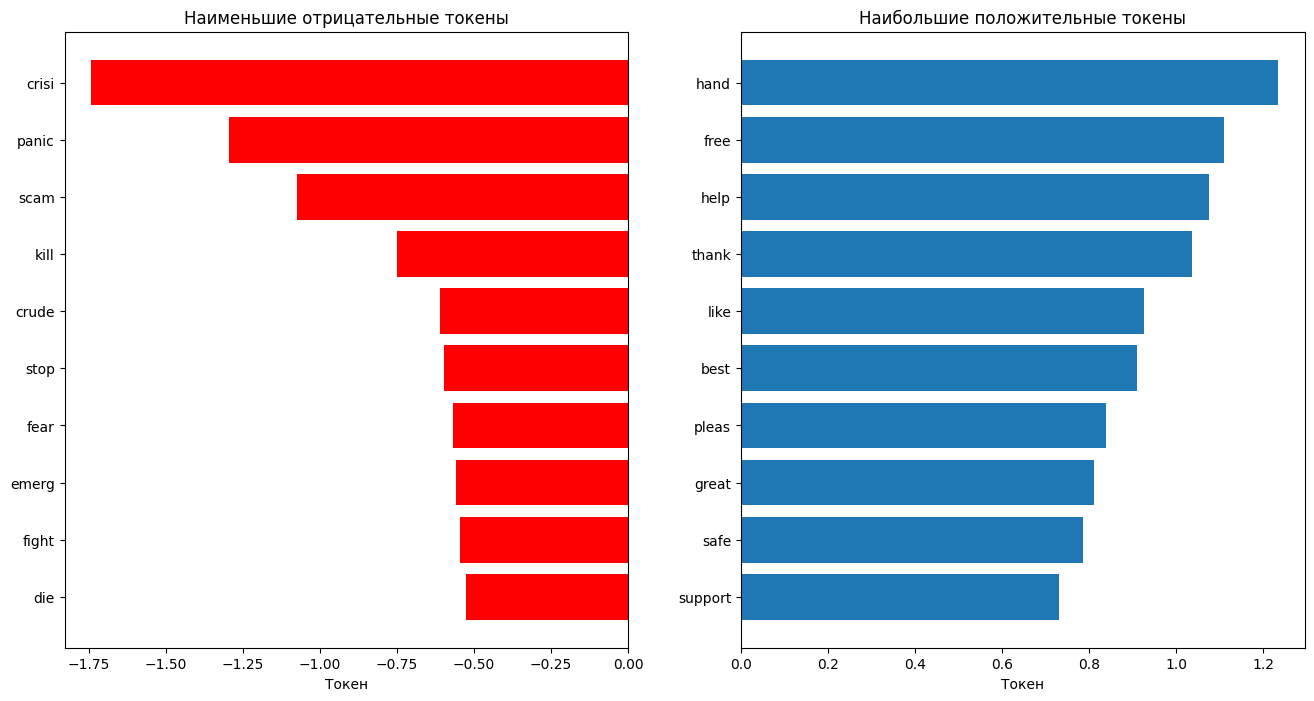

In [48]:
tokens = cv_df.get_feature_names_out()
cfs = lr_cv.coef_[0]

best_pos = np.argsort(cfs)[-10:][::-1]
least_neg = np.argsort(cfs)[:10]

tokens_pos = tokens[best_pos]
values_pos = cfs[best_pos]

tokens_neg = tokens[least_neg]
values_neg = cfs[least_neg]

fig, axes = plt.subplots(1, 2, figsize = (16, 8))

axes[1].barh(tokens_pos, values_pos)
axes[1].set_title("Наибольшие положительные токены")
axes[1].set_xlabel("Токен")
axes[1].invert_yaxis()

axes[0].barh(tokens_neg, values_neg, color = 'red')
axes[0].set_title("Наименьшие отрицательные токены")
axes[0].set_xlabel("Токен")
axes[0].invert_yaxis()

**Ответ:** Видно, что наибольшие положительные веса имеют токены, наиболее ассоциирующиеся с пощитивным комментом (SentimentBin = 1), в то время, как наименьшие отрицательные веса принимают наиболее негативные токены, которые синглизируют о негативости твита

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [49]:
train[['UserName', 'ScreenName', 'SentimentBin']].corr()

,UserName,ScreenName,SentimentBin
UserName,1.000000,1.000000,0.054568
ScreenName,1.000000,1.000000,0.054568
SentimentBin,0.054568,0.054568,1.000000


**Ответ:** По матрице корреляций можно сказать, что наша целевая переменная практически никак не коррелирует с именем пользователя и его псевдонимом, поэтому эти переменные бесполезны

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [50]:
train['TweetAt'] = pd.to_datetime(train['TweetAt'], format='%d-%m-%Y')
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23410 entries, 25621 to 2732
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   UserName       23410 non-null  int64         
 1   ScreenName     23410 non-null  int64         
 2   Location       23410 non-null  object        
 3   TweetAt        23410 non-null  datetime64[ns]
 4   OriginalTweet  23410 non-null  object        
 5   Sentiment      23410 non-null  object        
 6   SentimentBin   23410 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 1.4+ MB


<Axes: xlabel='TweetAt', ylabel='Count'>

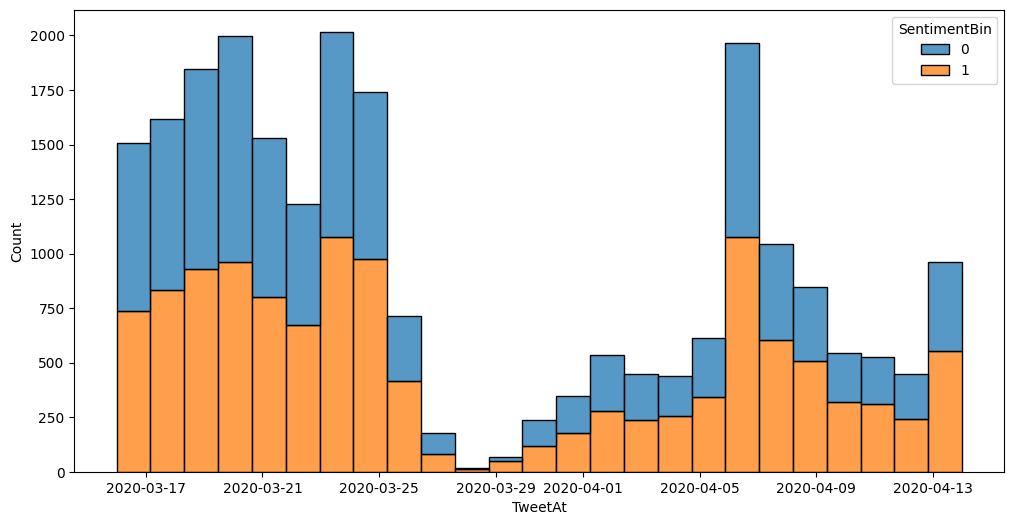

In [51]:
plt.figure(figsize=(12, 6))
sns.histplot(train, x = 'TweetAt', hue = 'SentimentBin', multiple='stack')

In [52]:
train[['TweetAt', 'SentimentBin']].corr()

,TweetAt,SentimentBin
TweetAt,1.000000,0.050304
SentimentBin,0.050304,1.000000


**Ответ:** Здесь аналогично имени и псевдониму нет интересующей нас достаточной корреляции для того, чтобы сказать, что дата твита является полезным признаком, что подтверждается графиком распределения твитов по дням (видно, что соотношение позитивных и негативных твитов почти в каждую дату 1:1)



Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [82]:
df.Location.nunique()

10465

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

<BarContainer object of 10 artists>

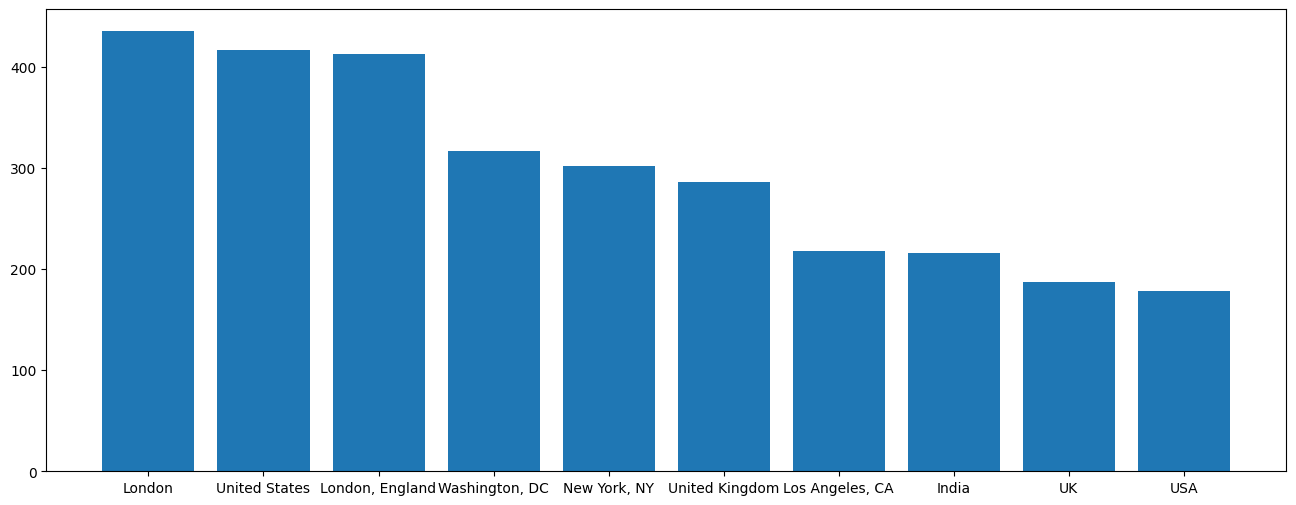

In [84]:
best_locations = df.loc[df['Location'] != 'Unknown', 'Location'].value_counts().head(10).reset_index()
plt.figure(figsize=(16, 6))
plt.bar(best_locations['Location'], best_locations['count'])

In [85]:
locations = df.loc[df['Location'] != 'Unknown', 'Location'].value_counts().reset_index()['Location']
cnts = df.loc[df['Location'] != 'Unknown', 'Location'].value_counts().reset_index()
cnts

,Location,count
0,London,435
1,United States,416
2,"London, England",413
3,"Washington, DC",317
4,"New York, NY",302
...,...,...
10459,No ManÃÂs Land,1
10460,Gaborone Botswana,1
10461,Mid Wales,1
10462,Northern Ontario,1


Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

<BarContainer object of 10 artists>

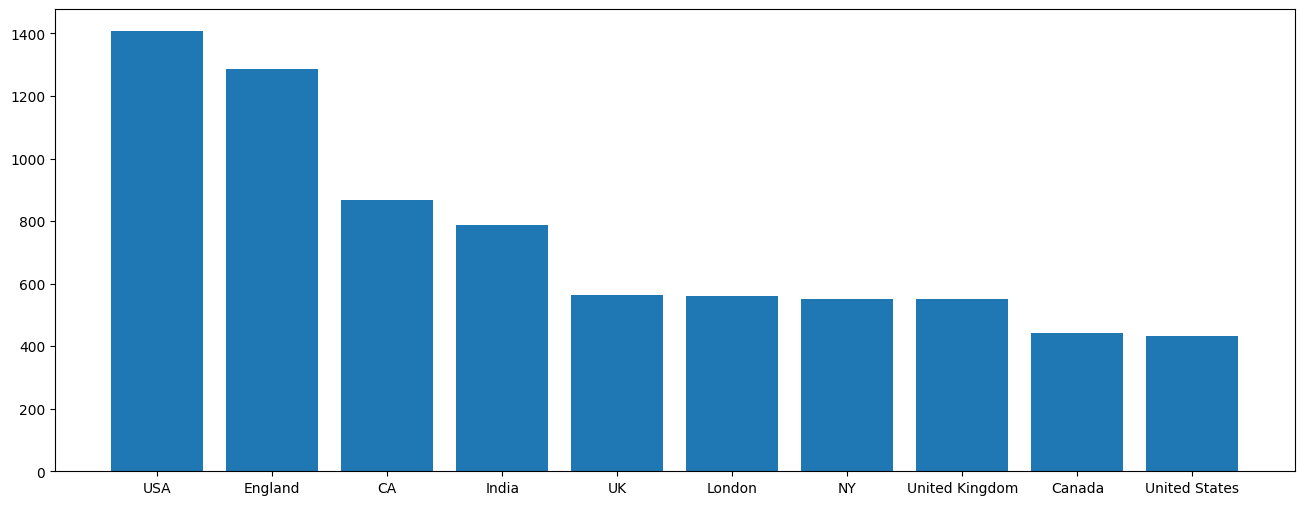

In [86]:
df['WiderLocation'] = df['Location'].apply(lambda k: k.split(',')[-1].strip())
best_locations_new = df.loc[df['WiderLocation'] != 'Unknown', 'WiderLocation'].value_counts().head(10).reset_index()
plt.figure(figsize=(16, 6))
plt.bar(best_locations_new['WiderLocation'], best_locations_new['count'])





In [87]:
df['WiderLocation'].nunique()

6118

В гистограмме теперь можно видеть соотношение популярностей твитов по странам локаций. Уникальных значений стало 6118, а было 10465 - уменьшилось в 1.7 раза так как мы схлопнули некоторые повторения местоположений до более широкой локации

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [88]:
from sklearn.preprocessing import OneHotEncoder

wider_loc = df.loc[df['Location'] != 'Unknown', 'Location'].value_counts()
wider_loc = wider_loc[wider_loc > 1].index.tolist()
train['WiderLocationOHE'] = df['WiderLocation'].where(df['WiderLocation'].isin(wider_loc),other=pd.NA)
ohe_loc = pd.get_dummies(train['WiderLocationOHE'], dummy_na=False)

ohe_loc = OneHotEncoder(categories=[wider_loc], handle_unknown='ignore', sparse_output=False)
X_loc = ohe_loc.fit_transform(train[['WiderLocation']])

len(wider_loc)

2336

2336 локаций, из которых были опубликованы твиты более 1 раза

Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [ ]:
train, test = train_test_split(df, test_size=0.3, random_state = 0)

scaler = StandardScaler(with_mean=False)

X = cv_df.transform(x_train)
X_test = cv_df.transform(x_test)

X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

X_arr = X.toarray()
X_test_arr = X_test.toarray()

X_full = np.concatenate([X_text_dense, X_loc], axis=1)

lr_cv = LogisticRegression(max_iter=200, random_state=28)
lr_cv.fit(X, y_train)
pred_cv_test = lr_cv.predict(X_test)
pred_cv_train = lr_cv.predict(X)

cv_acc_test = accuracy_score(y_test, pred_cv_test)
cv_acc_train = accuracy_score(y_train, pred_cv_train)

print("Test: ", cv_acc_test)
print("Train: ", cv_acc_train)

**Ответ:** # -- YOUR ANSWER HERE --